In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import os

import matplotlib.pyplot as plt
plt.style.use("~/mpl_styles/cs_paper.mplstyle")

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [6]:
import pickle
import pandas as pd
BASE = "../experiment_results/mnist_scan/"
files = os.listdir(BASE)

dfs = []
for f in files:
    dfs.append(pd.read_pickle(os.path.join(BASE, f)))

scan_results = pd.concat(dfs, ignore_index=True)

df_svd = scan_results[scan_results['optimizer'] == 'SVD']
df_baseline = scan_results[scan_results['optimizer'] != 'SVD']

In [13]:
batch_sizes = sorted(list(set(df_svd['batch_size'].values)))
k_fracs = sorted(list(set(df_svd['k_fraction'].values)))
lrs_svd = sorted(list(set(df_svd['lr'].values)))
lrs_baseline = sorted(list(set(df_baseline['lr'].values)))
mlp_widths = sorted(list(set(df_svd['mlp_width'].values)))
baseline_optimizers = df_baseline['optimizer'].unique().tolist()

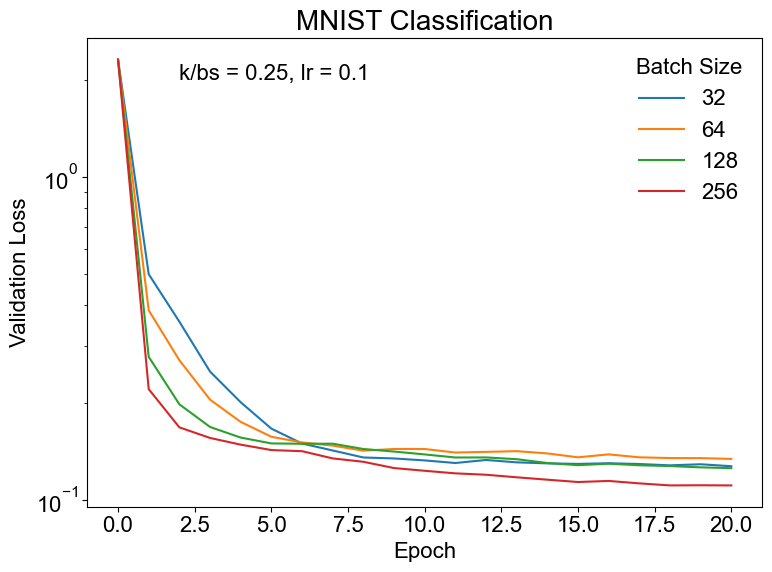

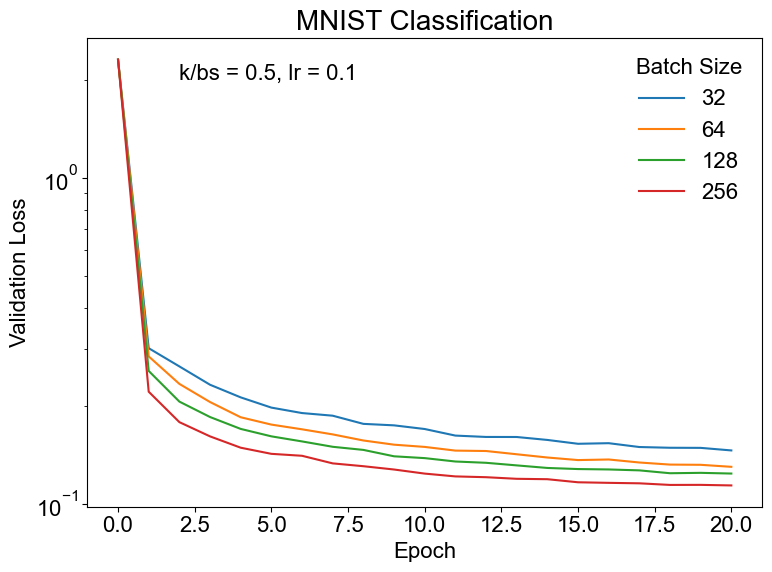

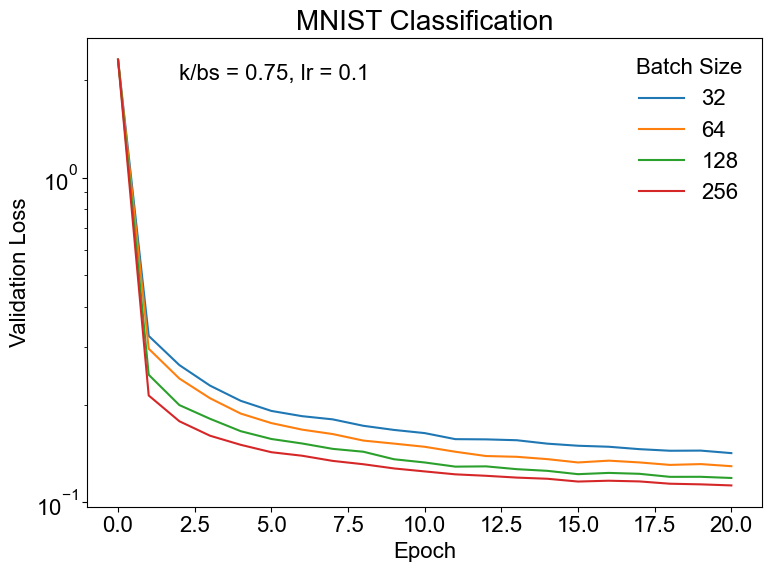

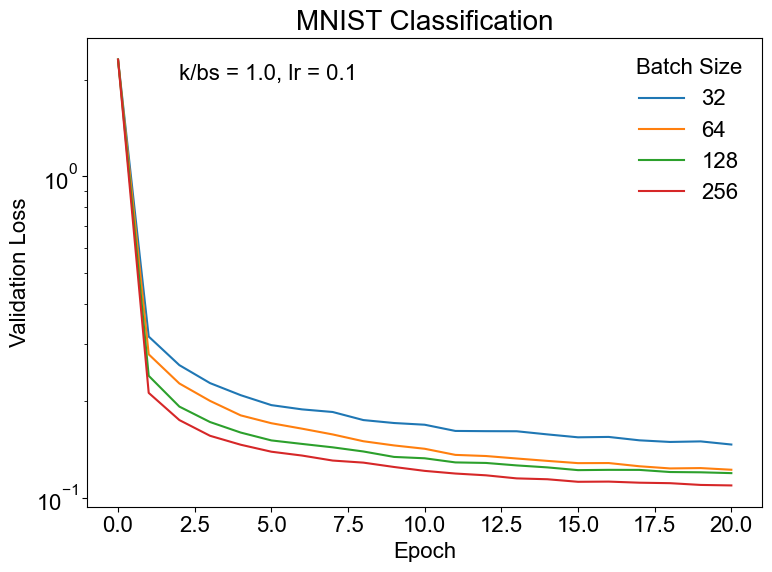

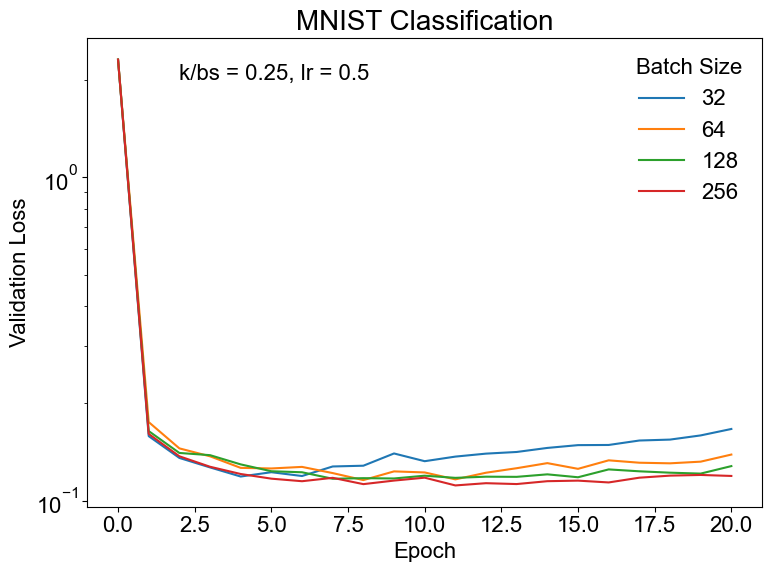

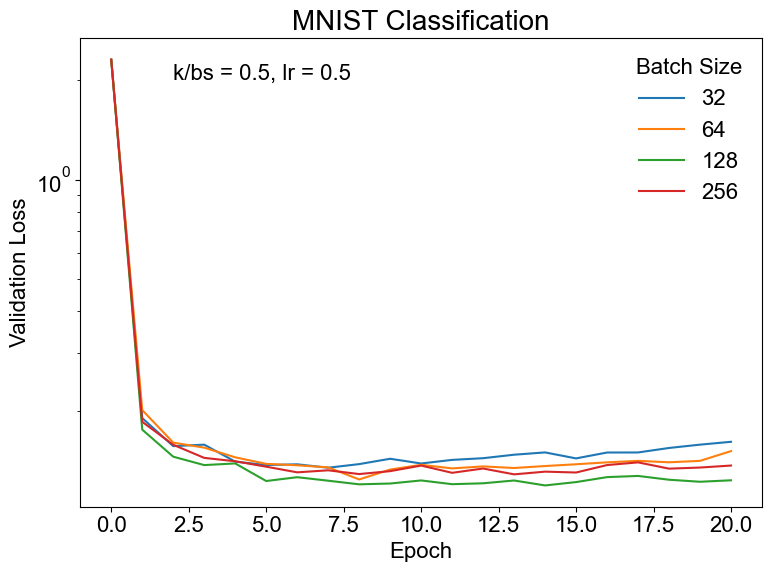

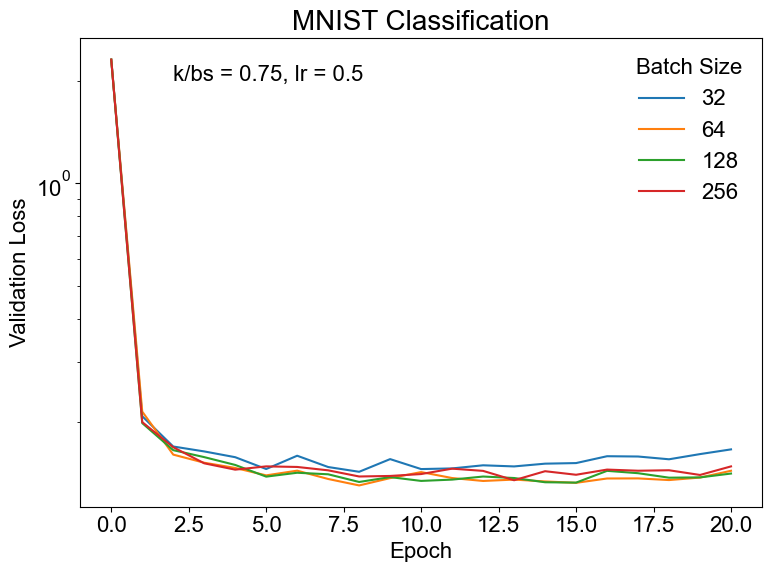

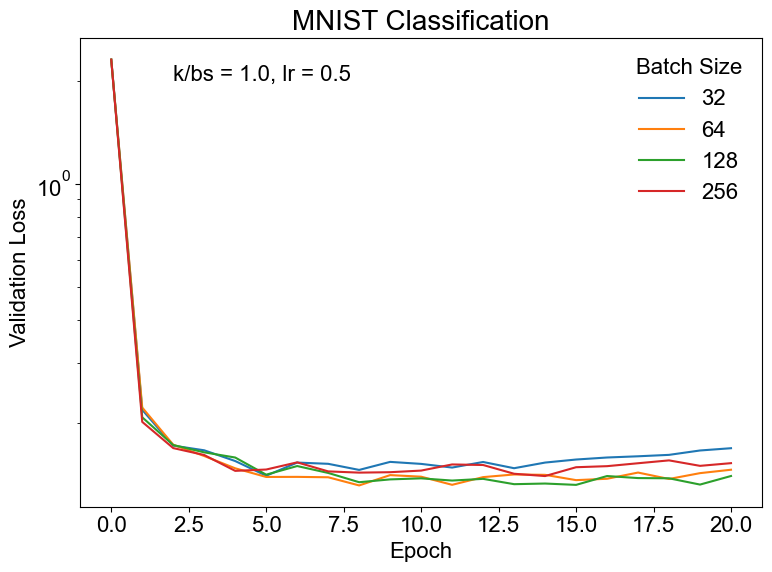

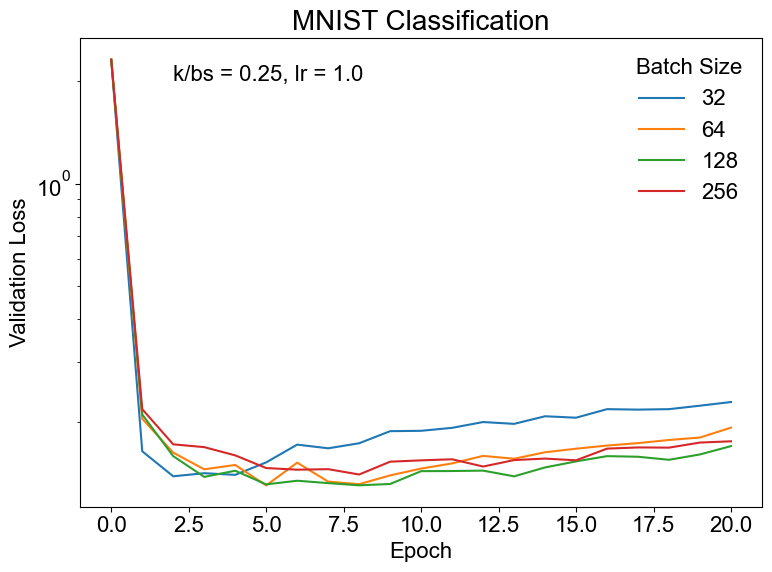

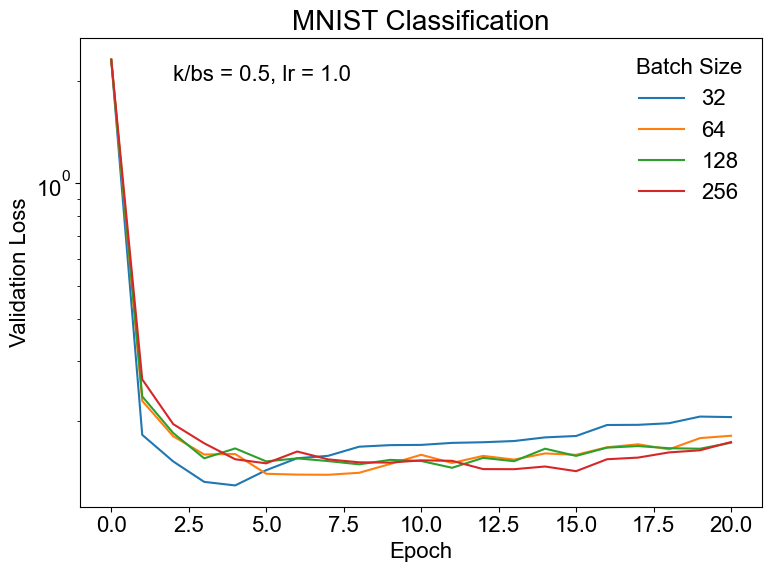

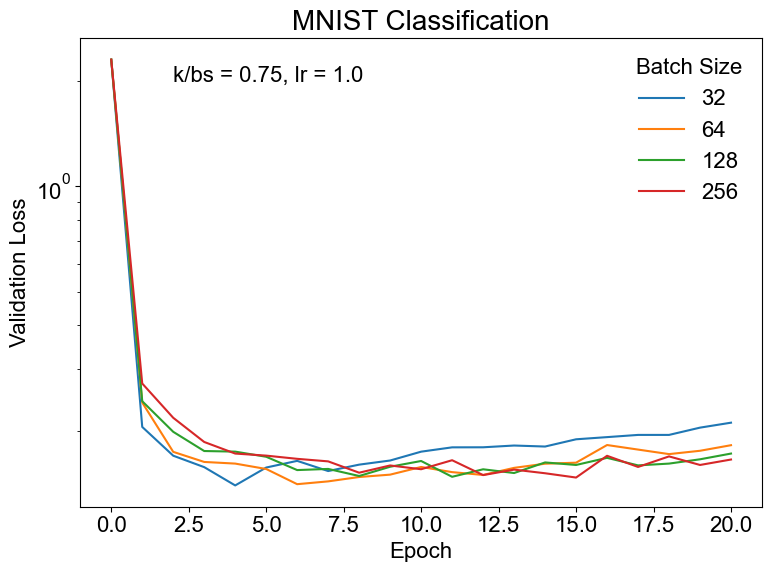

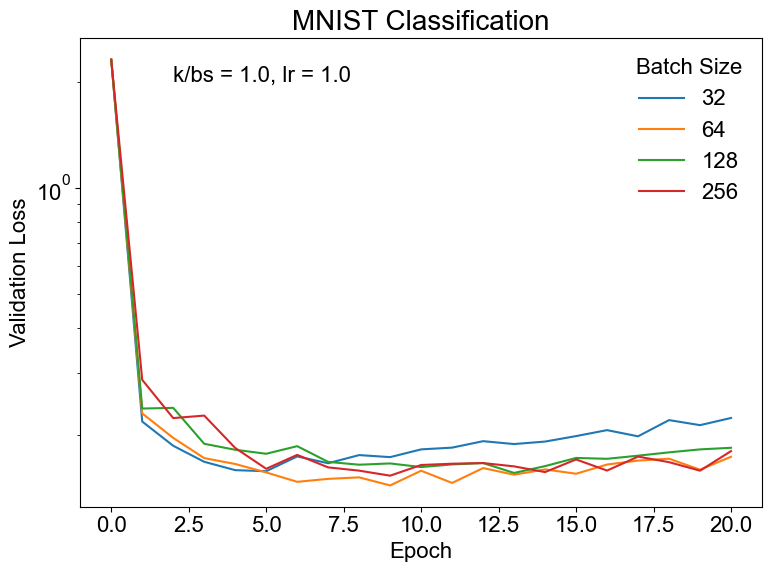

In [12]:
MLP_WIDTH = 64
for LR_VAL in lrs_svd:
    for K_FRAC in k_fracs:
        plt.figure(figsize=(8,6))
        for bs in batch_sizes:
            k = (bs,K_FRAC,LR_VAL)
            cut = (df_svd['batch_size'] == bs) & (df_svd['k_fraction'] == K_FRAC) & (df_svd['lr'] == LR_VAL) & (df_svd['mlp_width'] == MLP_WIDTH)
            res = df_svd[cut].iloc[0]
            xvals = np.arange(len(res['losses']['val']))
            plt.plot(xvals, res['losses']['val'], label=f'{bs}')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.yscale('log')
        plt.legend(title='Batch Size')
        plt.title(rf"MNIST Classification")
        plt.text(2,2,rf"k/bs = {K_FRAC}, lr = {LR_VAL}",fontsize=16)
        plt.tight_layout()
        plt.savefig(f"mnist_plots/mnist_val_loss_bsOverlay_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
        plt.show()

# Fix batch size, compare optimizers

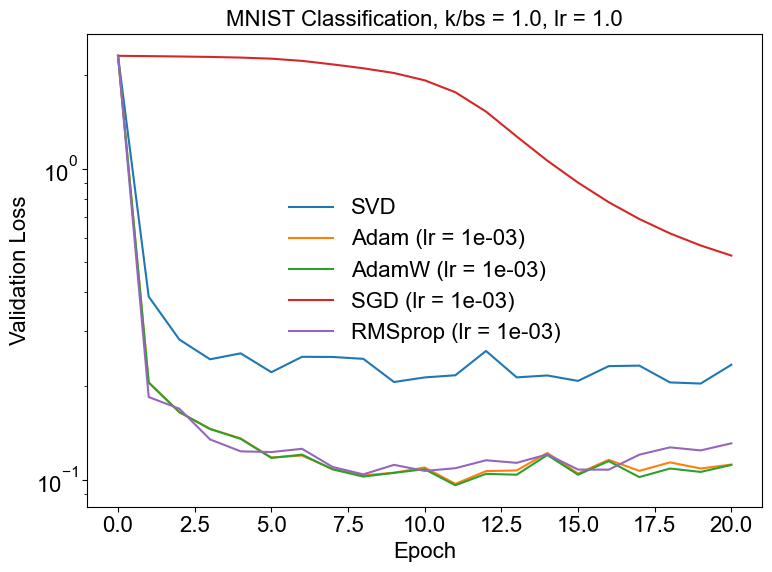

In [15]:
K_FRAC = 1.0 # full batch
LR_VAL = 1.0 # small-ish LR
MLP_WIDTH = 32
bs = 128
lr_normal = 1e-3

plt.figure(figsize=(8,6))
k = (bs,K_FRAC,LR_VAL)
cut = (df_svd['batch_size'] == bs) & (df_svd['k_fraction'] == K_FRAC) & (df_svd['lr'] == LR_VAL) & (df_svd['mlp_width'] == MLP_WIDTH)
res = df_svd[cut].iloc[0]
n_epoch = len(res['losses']['val'])
xvals = np.arange(len(res['losses']['val']))
plt.plot(xvals, res['losses']['val'], label=f'SVD')
for opt in baseline_optimizers:
    cut = (df_baseline['batch_size'] == bs) & (df_baseline['lr'] == lr_normal) & (df_baseline['optimizer'] == opt) & (df_baseline['mlp_width'] == MLP_WIDTH)
    res = df_baseline[cut].iloc[0]
    n_epoch = len(res['losses']['val'])
    xvals = np.arange(len(res['losses']['val']))
    plt.plot(xvals, res['losses']['val'], label=f'{opt} (lr = {lr_normal:.0e})')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification, k/bs = {K_FRAC}, lr = {LR_VAL}",fontsize=16)
plt.tight_layout()
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.show()


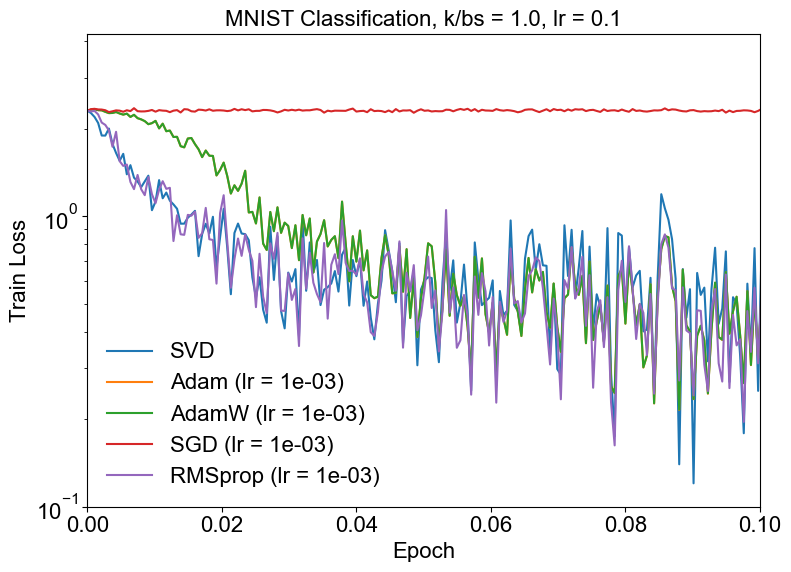

In [30]:
K_FRAC = 1.0 # full batch
LR_VAL = 0.1 # small-ish LR
MLP_WIDTH = 32
bs = 32
lr_normal = 1e-3

plt.figure(figsize=(8,6))

k = (bs,K_FRAC,LR_VAL)
cut = (df_svd['batch_size'] == bs) & (df_svd['k_fraction'] == K_FRAC) & (df_svd['lr'] == LR_VAL) & (df_svd['mlp_width'] == MLP_WIDTH)
res = df_svd[cut].iloc[0]
n_epoch = len(res['losses']['train'])
xvals = np.linspace(0,n_epoch,len(res['losses']['train_batch']))
plt.plot(xvals, res['losses']['train_batch'], label=f'SVD')
for opt in baseline_optimizers:
    cut = (df_baseline['batch_size'] == bs) & (df_baseline['lr'] == lr_normal) & (df_baseline['optimizer'] == opt) & (df_baseline['mlp_width'] == MLP_WIDTH)
    res = df_baseline[cut].iloc[0]
    n_epoch = len(res['losses']['train'])
    xvals = np.linspace(0,n_epoch,len(res['losses']['train_batch']))
    plt.plot(xvals, res['losses']['train_batch'], label=f'{opt} (lr = {lr_normal:.0e})')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification, k/bs = {K_FRAC}, lr = {LR_VAL}",fontsize=16)
plt.tight_layout()
plt.xlim([0,0.1])
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.ylim([1e-1,None])
plt.show()


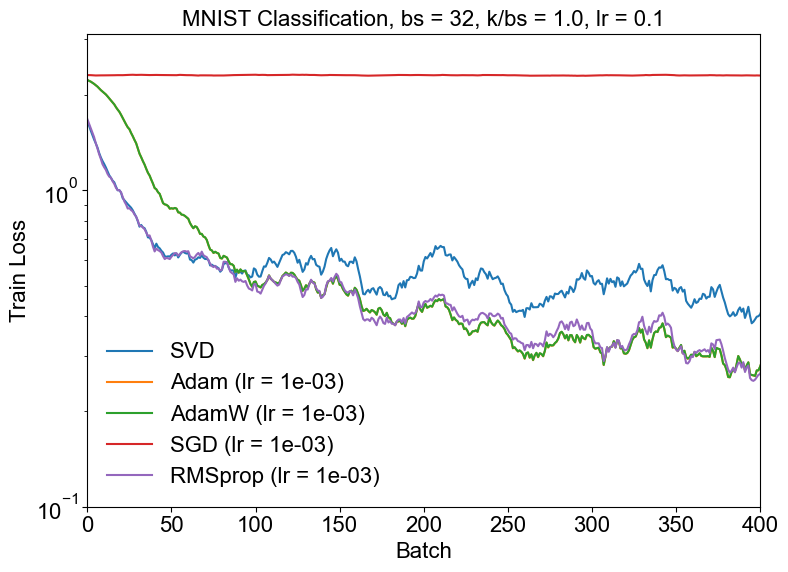

In [29]:
K_FRAC = 1.0 # full batch
LR_VAL = 0.1 # small-ish LR
MLP_WIDTH = 32
bs = 32
lr_normal = 1e-3

smoothing = 20

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='valid')
    return y_smooth

plt.figure(figsize=(8,6))

k = (bs,K_FRAC,LR_VAL)
cut = (df_svd['batch_size'] == bs) & (df_svd['k_fraction'] == K_FRAC) & (df_svd['lr'] == LR_VAL) & (df_svd['mlp_width'] == MLP_WIDTH)
res = df_svd[cut].iloc[0]
n_epoch = len(res['losses']['train'])
yvals = smooth(res['losses']['train_batch'], smoothing)
plt.plot(yvals, label=f'SVD')

for opt in baseline_optimizers:
    cut = (df_baseline['batch_size'] == bs) & (df_baseline['lr'] == lr_normal) & (df_baseline['optimizer'] == opt) & (df_baseline['mlp_width'] == MLP_WIDTH)
    res = df_baseline[cut].iloc[0]
    n_epoch = len(res['losses']['train'])
    yvals = smooth(res['losses']['train_batch'], smoothing)
    plt.plot(yvals, label=f'{opt} (lr = {lr_normal:.0e})')

plt.legend()
plt.xlabel('Batch')
plt.ylabel('Train Loss')
plt.yscale('log')
plt.title(rf"MNIST Classification, bs = {bs}, k/bs = {K_FRAC}, lr = {LR_VAL}",fontsize=16)
plt.tight_layout()
plt.xlim([0,400])
#plt.savefig(f"mnist_plots/mnist_val_loss_individual_bs_{bs}_kfrac_{K_FRAC}_lr_{LR_VAL}.pdf",bbox_inches='tight')
plt.ylim([1e-1,None])
plt.show()
